In [176]:
import glob
import os

import tifffile as tiff
from scipy import ndimage as ndi
from skimage import morphology
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def graph(path: str, connectivity: int = 2):
    # 連結成分でグラフを作成する
    G = nx.Graph()
    frames = tiff.imread(path)
    for slice_index, frame in enumerate(frames):
        if slice_index == 30:
            break
        structure = ndi.generate_binary_structure(rank=2, connectivity=connectivity)
        # labels: ラベル画像, num: ラベルの数
        labels, num = ndi.label(frame, structure=structure)
        # 一つ前のスライスとの積を考え、ラベルが重なっているラベル間にエッジを張る
        if slice_index > 0:
            prev_frame = frames[slice_index - 1]
            prev_labels, _ = ndi.label(prev_frame, structure=structure)
            for label in range(1, num + 1):
                mask = labels == label
                overlapping_labels = np.unique(prev_labels[mask])
                for overlapping_label in overlapping_labels:
                    if overlapping_label != 0: # 背景は無視
                        G.add_edge((slice_index - 1, overlapping_label), (slice_index, label))
        for label in range(1, num + 1):
            # 面積もノードの属性として追加する
            area = np.sum(labels == label)
            G.add_node((slice_index, label), area=area)
        # スライス全体を表すノードも追加
        G.add_node((slice_index, 'S'))

    # --- アルゴリズム: 閾値以上のノードを検出し、前スライスのつながりを調べる ---
    threshold = 500
    red_nodes = set()
    edges_to_remove = []
    for node in G.nodes:
        slice_index, label = node
        # スライス先頭ノードや 'S' ノードはスキップ
        if label == 'S' or slice_index == 0:
            continue
        area = G.nodes[node].get('area', 0)
        if area < threshold:
            continue
        # 前スライスのノードでつながっているものを調べる
        neighbors = [n for n in G.neighbors(node) if n[0] == slice_index - 1]
        # 閾値以上のノードを抽出
        large_neighbor_nodes = [n for n in neighbors if G.nodes[n].get('area', 0) >= threshold]
        if len(large_neighbor_nodes) >= 2:
            # 赤色にするノードは直前スライス側（小さい値）
            for large_neighbor_node in large_neighbor_nodes:
            # これ以下のslice_indexですでに赤色ノードが存在する場合は無視
                search_red_node = [n for n in nx.node_connected_component(G, large_neighbor_node)
                                   if (n in red_nodes) and (n[0] <= slice_index - 1)]
                if search_red_node:
                    continue
                red_nodes.add(large_neighbor_node)
                if G.has_edge(large_neighbor_node, node):
                    edges_to_remove.append((large_neighbor_node, node))

    # エッジ削除
    # G.remove_edges_from(edges_to_remove)

    # --- 描画 ---
    pos = {}
    for node in G.nodes:
        slice_index, label = node
        if label == 'S':
            pos[node] = (0, slice_index) # 左端
        else:
            pos[node] = (label, slice_index) # x:スライス順, y:ラベル番号で上下にずらす
    plt.figure(figsize=(12, 20))
    labels = {}
    for node in G.nodes:
        if node[1] == 'S':
            labels[node] = f"slice {node[0]}"
        else:
            labels[node] = f"{G.nodes[node]['area']}"
    node_colors = []
    for node in G.nodes:
        if node in red_nodes:
            node_colors.append('red')
        else:
            node_colors.append('skyblue')
    nx.draw(G, pos=pos, with_labels=True, labels=labels, node_color=node_colors)


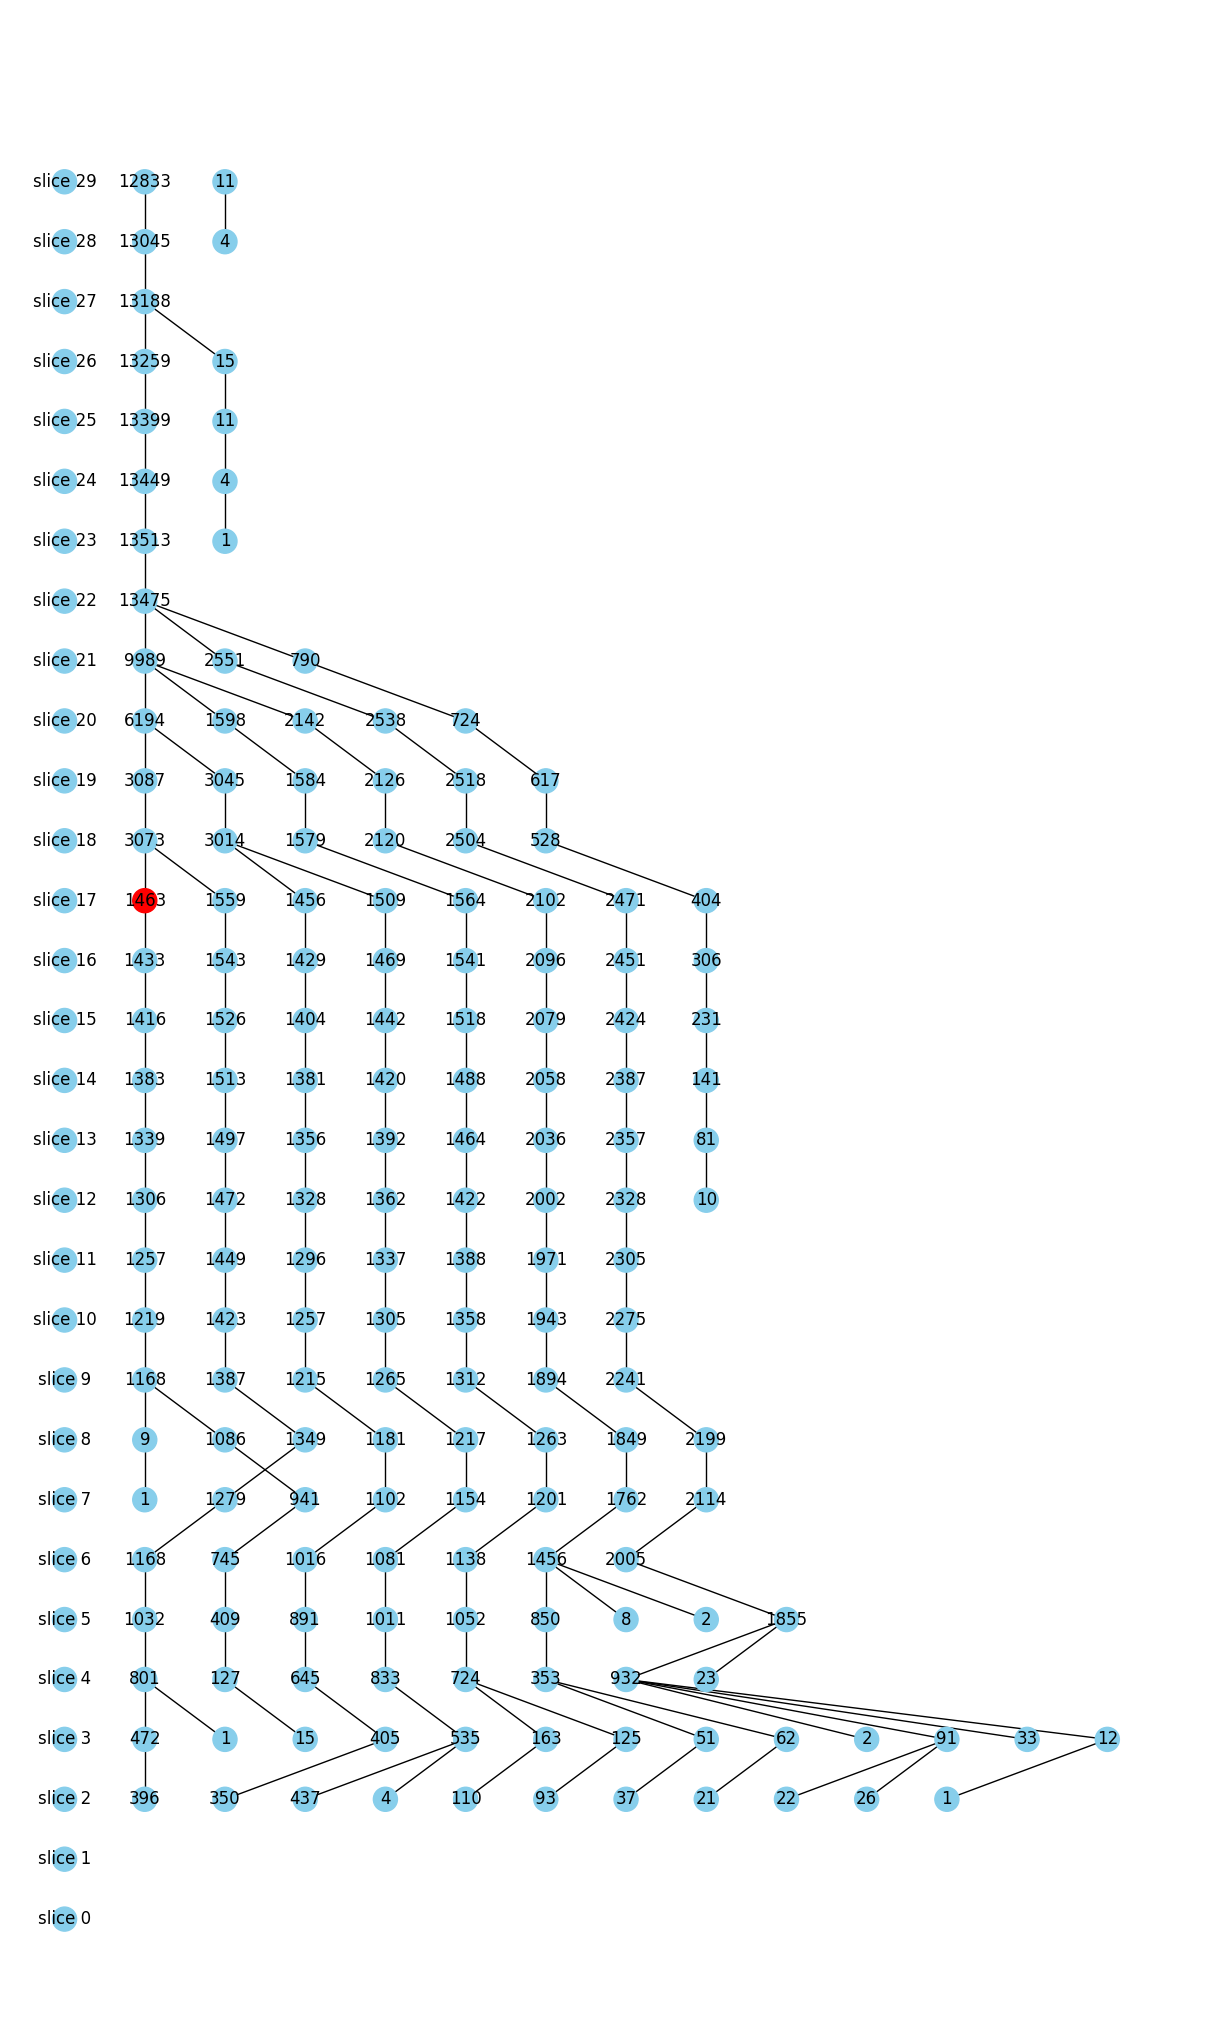

In [177]:
if __name__ == "__main__":
    path = r"D:\_study\ImageProcessing\study\Watershed\Data\Input\20260421_filled255_No1\label_map_1_filled.tif"
    graph(path, connectivity=2)